In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pylab import rcParams
from pathlib import Path

# Analysis of our cleaned data

In [3]:
#I am going to make a directory so I can have easy access to our graphs 
Path("figures").mkdir(parents=True, exist_ok=True)

#Default figure size in the "figure" directory
rcParams['figure.figsize'] = (4, 4)

#Telling pandas how to display floats
pd.options.display.float_format = "{:,.2f}".format

### Load and validate our cleaned data 

In [4]:
path = "data/wti_cleaned.csv"
path_alb = "data/alberta_production_wide.csv"
#Earlier we parsed the dates but it did not seem to work, so we will tell PD to parse dates here.
data = pd.read_csv(path, parse_dates=["date"])
data_alb = pd.read_csv(path_alb, parse_dates=["date"])

In [5]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5036 entries, 0 to 5035
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    5036 non-null   datetime64[ns]
 1   price   5036 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 78.8 KB


,date,price
0,2007-01-01,60.85
1,2007-01-02,60.77
2,2007-01-03,58.31
3,2007-01-04,55.65
4,2007-01-05,56.29


In [6]:
data_alb.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  230 non-null    datetime64[ns]
 1   Conventional Oil      230 non-null    float64       
 2   Non-Conventional Oil  230 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 5.5 KB


,date,price
0,2007-01-01,60.85
1,2007-01-02,60.77
2,2007-01-03,58.31
3,2007-01-04,55.65
4,2007-01-05,56.29


## Data Processing for FRED data

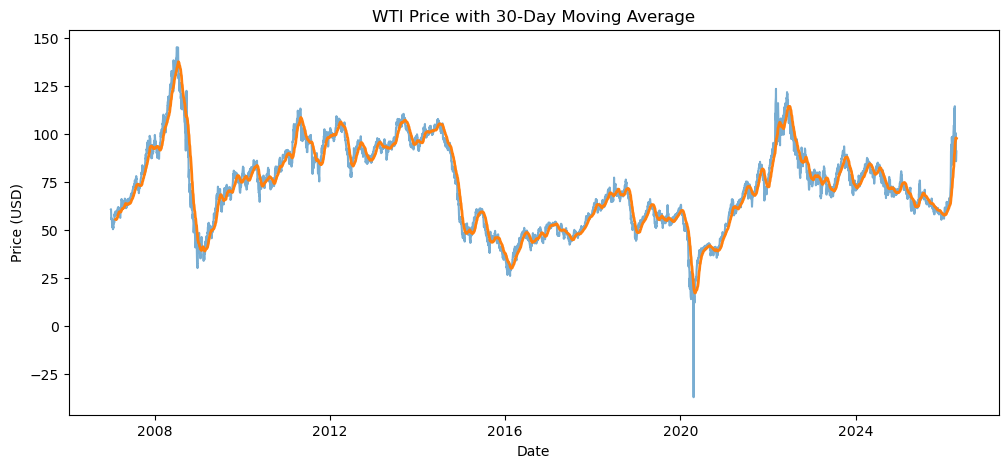

In [8]:
data["MA30"] = data["price"].rolling(30).mean()
plt.figure(figsize=(12,5))
plt.plot(data["date"], data["price"], alpha=0.6)
plt.plot(data["date"], data["MA30"], linewidth=2)
plt.title("WTI Price with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.savefig("figures/wti_moving_average.png")
plt.show()

In [19]:
#Only the first 29 values in our new column should be NaN. The right data is being loaded and processed.
data["MA30"].isna().sum()

np.int64(29)

## Data Processing for Alberta data

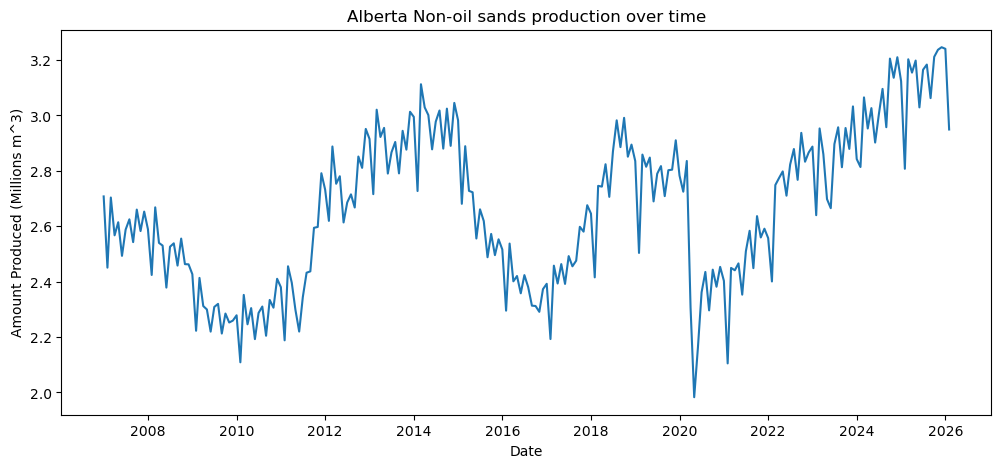

In [20]:
plt.figure(figsize=(12,5))
plt.plot(data_alb["date"], data_alb["Conventional Oil"]/1e6)
plt.title("Alberta Non-oil sands production over time")
plt.xlabel("Date")
plt.ylabel("Amount Produced (Millions m^3)")
plt.savefig("figures/non_oil_sands_production")
plt.show()

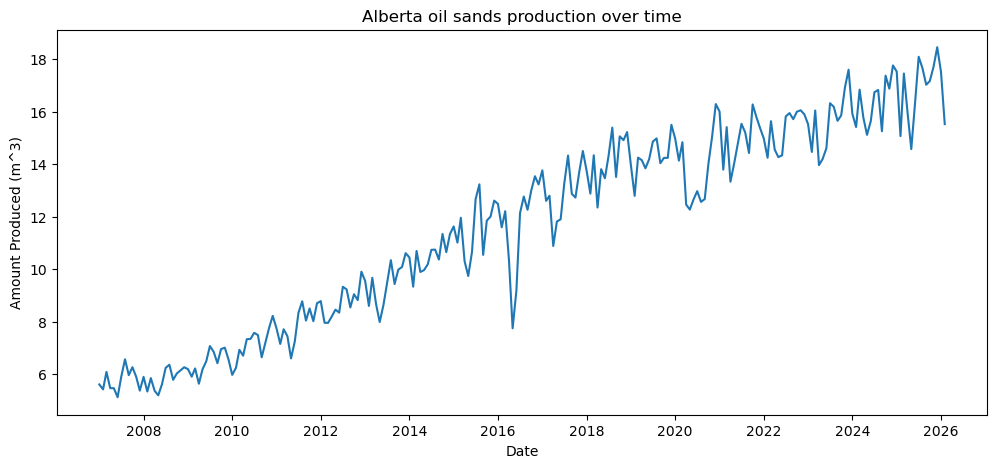

In [21]:
plt.figure(figsize=(12,5))
plt.plot(data_alb["date"], data_alb["Non-Conventional Oil"]/1e6)
plt.title("Alberta oil sands production over time")
plt.xlabel("Date")
plt.ylabel("Amount Produced (m^3)")
plt.savefig("figures/oil_sands_production")
plt.show()

In [22]:
wti_monthly = data.groupby("date")["price"].mean()
merged = pd.merge(wti_monthly, data_alb, on="date")
merged.head()

,date,price,Conventional Oil,Non-Conventional Oil
0,2007-01-01,60.85,"2,707,743.40","5,604,533.20"
1,2007-02-01,57.35,"2,450,594.20","5,414,892.80"
2,2007-03-01,61.97,"2,703,836.80","6,082,110.50"
3,2007-05-01,64.43,"2,614,545.20","5,460,600.20"
4,2007-06-01,65.09,"2,493,203.40","5,116,667.30"


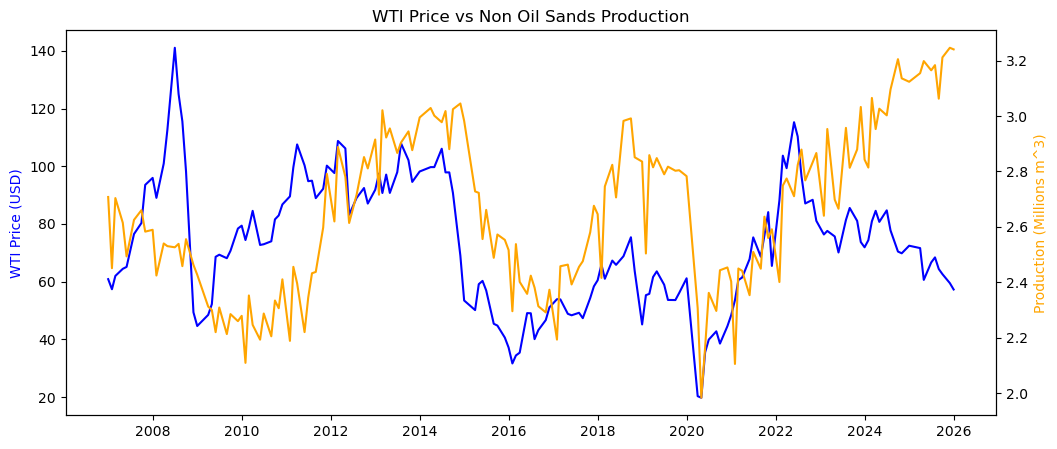

In [32]:
fig, ax1 = plt.subplots(figsize=(12,5))

#Left axis (WTI)
ax1.plot(merged["date"], merged["price"], color="blue")
ax1.set_ylabel("WTI Price (USD)", color="blue")

#Right axis (Non Oil Sands)
ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["Conventional Oil"]/1e6, color="orange")
ax2.set_ylabel("Production (Millions m^3)", color="orange")

plt.title("WTI Price vs Non Oil Sands Production")
plt.savefig("figures/non_oil_sands_production_vs_wti_price")
plt.show()

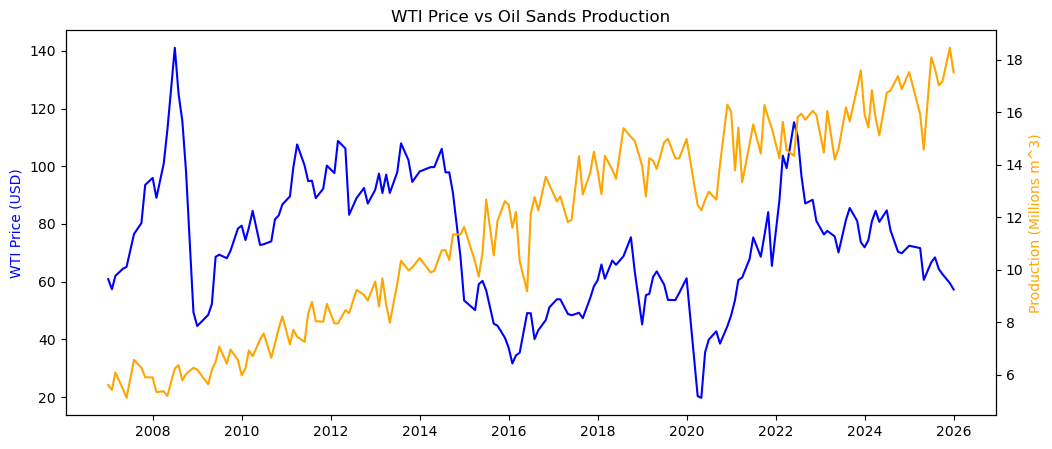

In [23]:
fig, ax1 = plt.subplots(figsize=(12,5))

#Left axis (WTI)
ax1.plot(merged["date"], merged["price"], color="blue")
ax1.set_ylabel("WTI Price (USD)", color="blue")

#Right axis (Oil Sands)
ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["Non-Conventional Oil"]/1e6, color="orange")
ax2.set_ylabel("Production (Millions m^3)", color="orange")

plt.title("WTI Price vs Oil Sands Production")
plt.savefig("figures/oil_sands_production_vs_wti_price")
plt.show()

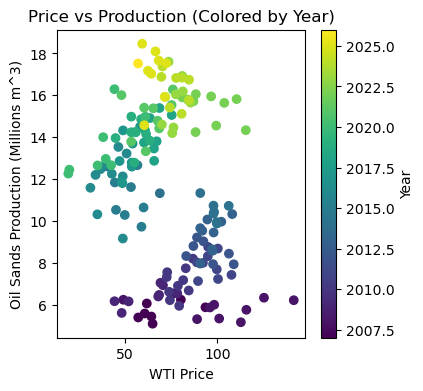

In [44]:
plt.scatter(merged["price"], merged["Non-Conventional Oil"]/1e6, c=merged["date"].dt.year, cmap="viridis")
plt.colorbar(label="Year")
plt.xlabel("WTI Price")
plt.ylabel("Oil Sands Production (Millions m^3)")
plt.title("Price vs Production (Colored by Year)")
plt.savefig("figures/oil_sands_production_vs_wti_price_scatter")
plt.show()

## Computing the Correlation for Non Oil Sands Production

In [38]:
merged["price"].corr(merged["Conventional Oil"])

np.float64(0.27464081177256555)

In [39]:
merged["prod_change_conventional"] = merged["Conventional Oil"].diff()
merged["price_change"] = merged["price"].diff()
merged["price_change"].corr(merged["prod_change_conventional"])

np.float64(0.21440690623401765)

In [40]:
merged["price_lag_6"] = merged["price"].shift(6)
merged["price_lag_12"] = merged["price"].shift(12)

In [44]:
merged["price_lag_6"].corr(merged["prod_change_conventional"])

np.float64(-0.01804822626870865)

In [45]:
merged["price_lag_12"].corr(merged["prod_change_conventional"])

np.float64(-0.03633200772235906)

## Computing the Correlation for Oil Sands Production

In [51]:
merged["price"].corr(merged["Non-Conventional Oil"])

np.float64(-0.28662681980944615)

In [52]:
merged["prod_change"] = merged["Non-Conventional Oil"].diff()
merged["price_change"].corr(merged["prod_change"])

np.float64(0.18146524847458034)

In [53]:
merged["price_lag_6"].corr(merged["prod_change"])

np.float64(-0.008707160969513923)

In [54]:
merged["price_lag_12"].corr(merged["prod_change"])

np.float64(0.021848732825489266)